In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmadshogran/arabic-sentiment-texts")

print("Path to dataset files:", path)

100%|██████████| 57.5M/57.5M [00:00<00:00, 76.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahmadshogran/arabic-sentiment-texts/versions/1


In [2]:
import os
import pandas as pd

print(os.listdir(path))

df = pd.read_csv(path + "/final_data_ar_sentiment.csv")
df.head()

['final_data_ar_sentiment.csv']


,Unnamed: 0,label,text
0,0,0,نصيحه ما عمرك اتنزل لعبه سوبر ماريو مش زي ما ك...
1,1,1,❤️❤️❤️مجله 💭 👑
2,2,0,يعني بموافقتنا لان دمشق صايره موسكو
3,3,0,قايد في الحرس يعترف بفقدان السيطره الامنيه في ...
4,4,0,شوال الفلوس سويرس مشغول اوي اليومين دول بقناه ...


In [3]:
print("Number of samples:", len(df))
print()
print(df['label'].value_counts())
print()
print(df.isnull().sum())
print(df.duplicated().sum())
df['length'] = df['text'].fillna('').apply(len)
df['length'].describe()

Number of samples: 338721

label
1    170500
0    168221
Name: count, dtype: int64

Unnamed: 0     0
label          0
text          61
dtype: int64
0


,length
count,338721.000000
mean,327.252890
std,187.608896
min,0.000000
25%,170.000000
50%,292.000000
75%,456.000000
max,1702.000000


In [4]:
df = df.dropna(subset=['text'])

df = df.copy()

df.loc[:,'label'] = df['label'].map({0: 'neg', 1: 'pos'})

/tmp/ipykernel_691/2786139743.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['neg' 'pos' 'neg' ... 'neg' 'neg' 'neg']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:,'label'] = df['label'].map({0: 'neg', 1: 'pos'})


In [5]:
df.loc[:, 'text'] = df['text'].apply(lambda x: " ".join(x.split()[:150]))

In [6]:
df.head()

,Unnamed: 0,label,text,length
0,0,neg,نصيحه ما عمرك اتنزل لعبه سوبر ماريو مش زي ما ك...,90
1,1,pos,❤️❤️❤️مجله 💭 👑,14
2,2,neg,يعني بموافقتنا لان دمشق صايره موسكو,35
3,3,neg,قايد في الحرس يعترف بفقدان السيطره الامنيه في ...,70
4,4,neg,شوال الفلوس سويرس مشغول اوي اليومين دول بقناه ...,110


In [7]:
import re
from nltk.stem.isri import ISRIStemmer

stemmer = ISRIStemmer()
def clean_tweet(text):
    text = re.sub(r'http\S+|www.\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\sء-ي]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [stemmer.stem(w) for w in words]

    return " ".join(words)

In [8]:
df['clean_text'] = df['text'].fillna('').apply(clean_tweet)

In [9]:
df.head()

,Unnamed: 0,label,text,length,clean_text
0,0,neg,نصيحه ما عمرك اتنزل لعبه سوبر ماريو مش زي ما ك...,90,نصح ما عمر نزل لعب وبر ارو مش زي ما كنا توقع ا...
1,1,pos,❤️❤️❤️مجله 💭 👑,14,جله
2,2,neg,يعني بموافقتنا لان دمشق صايره موسكو,35,يعن وفق لان دمشق صير وسكو
3,3,neg,قايد في الحرس يعترف بفقدان السيطره الامنيه في ...,70,قيد في حرس عرف فقد يطر امن في شرق غرب اير حوز
4,4,neg,شوال الفلوس سويرس مشغول اوي اليومين دول بقناه ...,110,شول فلس يرس شغل اوي يوم دول بقن جزر نزل شتم تر...


In [10]:
X = df['clean_text']
y = df['label']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=9000,ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced',max_iter=200)
lr.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [14]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test_vec)))

Logistic Regression:
              precision    recall  f1-score   support

         neg       0.88      0.88      0.88     33641
         pos       0.88      0.88      0.88     34091

    accuracy                           0.88     67732
   macro avg       0.88      0.88      0.88     67732
weighted avg       0.88      0.88      0.88     67732



In [15]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

MultinomialNB()

In [16]:
print("Naive Bayes:")
print(classification_report(y_test, nb.predict(X_test_vec)))

Naive Bayes:
              precision    recall  f1-score   support

         neg       0.84      0.84      0.84     33641
         pos       0.85      0.85      0.85     34091

    accuracy                           0.85     67732
   macro avg       0.85      0.85      0.85     67732
weighted avg       0.85      0.85      0.85     67732



In [17]:
print("Accuracy LR:", lr.score(X_test_vec, y_test))
print("Accuracy NB:", nb.score(X_test_vec, y_test))

Accuracy LR: 0.8813411681332309
Accuracy NB: 0.8453168369456092


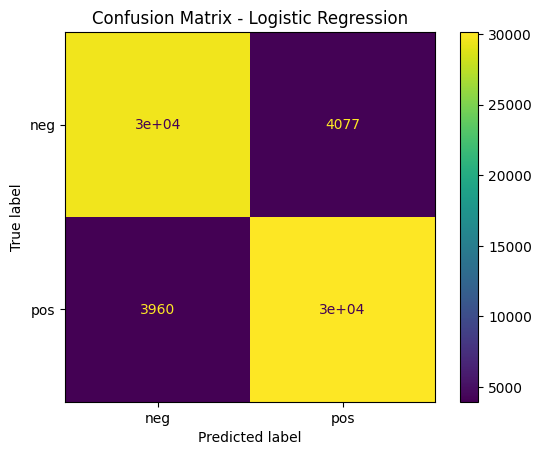

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
cm = confusion_matrix(y_test, lr.predict(X_test_vec))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()